# 01. Carga inicial del dataset

Este notebook documenta la carga dos de los cuatro ficheros CSV que componen
el dataset [Takeaway Food Orders](https://www.kaggle.com/datasets/henslersoftware/19560-indian-takeaway-orders),
seleccionado como caso de validación del sistema (ver apartado 4.3 del TFG).

El dataset contiene los pedidos realizados a dos restaurantes de comida
india para llevar ubicados en Londres entre septiembre de 2015 y agosto
de 2019, junto con el catálogo de productos y precios de cada uno.

El objetivo de esta fase es:

1. Cargar los dos ficheros originales DE UNO DE LOS RESTAURANTES sin modificarlos.
2. Inspeccionar su estructura y tipos de datos.
4. Dejar el dataset preparado para el enriquecimiento con variables
   contextuales (meteorología y festivos) que se realizará en el
   notebook siguiente.

## 1. Configuración de rutas

Se definen las rutas a los cuatro ficheros del dataset y se comprueba que
están disponibles antes de continuar. Se utiliza `pathlib.Path` para
garantizar la compatibilidad entre sistemas operativos (RNF09).

In [23]:
import pandas as pd
from pathlib import Path

# Configuración del restaurante a procesar
RESTAURANTE = 2 # Restaurante elegido para el estudio. (Cambiar 1 o 2 según el restaurante que se quiera procesar)

# Rutas base del proyecto
DATA_RAW = Path("../data/raw/kaggle_london_indian_takeaway")

# Ficheros del dataset
FICHEROS = {
    "pedidos": DATA_RAW / f"restaurant-{RESTAURANTE}-orders.csv",
    "precios": DATA_RAW / f"restaurant-{RESTAURANTE}-products-price.csv",
}

# Verificamos que los cuatro ficheros existen antes de continuar
for nombre, ruta in FICHEROS.items():
    assert ruta.exists(), f"No se encuentra {nombre} en {ruta}"
    print(f"✓ {nombre}: {ruta.name} ({ruta.stat().st_size / 1024:.1f} KB)")

✓ pedidos: restaurant-2-orders.csv (5339.4 KB)
✓ precios: restaurant-2-products-price.csv (6.5 KB)


## 2. Inspección inicial

Antes de realizar cualquier transformación se inspeccionan los dos
ficheros originales para confirmar su estructura, el nombre
de las columnas y los tipos de datos deducidos por pandas. 

In [24]:
# Cargamos los dos ficheros y echamos un vistazo a su estructura
dfs = {nombre: pd.read_csv(ruta) for nombre, ruta in FICHEROS.items()}

for nombre, df in dfs.items():
    print(f"\n{'-' * 60}")
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"\nColumnas: {list(df.columns)}")
    print(f"\nPrimeras 3 filas:")
    print(df.head(3))
    print(f"\nTipos de datos:")
    print(df.dtypes)


------------------------------------------------------------
pedidos: 119,183 filas × 6 columnas

Columnas: ['Order ID', 'Order Date', 'Item Name', 'Quantity', 'Product Price', 'Total products']

Primeras 3 filas:
   Order ID        Order Date             Item Name  Quantity  Product Price  \
0     25583  03/08/2019 21:58  Tandoori Mixed Grill         1          11.95   
1     25583  03/08/2019 21:58          Madras Sauce         1           3.95   
2     25583  03/08/2019 21:58         Mushroom Rice         2           3.95   

   Total products  
0              12  
1              12  
2              12  

Tipos de datos:
Order ID            int64
Order Date            str
Item Name             str
Quantity            int64
Product Price     float64
Total products      int64
dtype: object

------------------------------------------------------------
precios: 302 filas × 2 columnas

Columnas: ['Item Name', 'Product Price']

Primeras 3 filas:
       Item Name  Product Price
0  Onion C

## 3. Unificación de los pedidos de ambos restaurantes (para poder estudiar ambos por separado en caso necesario)

Los ficheros de pedidos de los dos restaurantes presentan la misma
estructura pero el nombre de la columna id es distinta
(`Order Number` en el restaurante 1 y `Order ID` en el restaurante 2).

Para construir un único DataFrame de pedidos que valga para los dos restaurantes se renombran las columnas para unificar los nombres

Los ficheros de precios (`precios_r1` y `precios_r2`) no se incorporan
al DataFrame principal, ya que el sistema predice el número de pedidos
(no su facturación) y el precio unitario no interviene en esa predicción.

In [25]:
# 1. Renombramos columnas del restaurante 2 para unificar esquemas
if RESTAURANTE == 2:
    dfs["pedidos"] = dfs["pedidos"].rename(columns={"Order ID": "Order Number"})

# 3. Concatenamos en un único DataFrame
pedidos = pd.concat(
    [dfs["pedidos"]],
    ignore_index=True
)

# 4. Normalizamos los nombres de columna a snake_case para el resto del análisis
pedidos = pedidos.rename(columns={
    "Order Number": "order_id",
    "Order Date": "order_datetime",
    "Item Name": "item_name",
    "Quantity": "quantity",
    "Product Price": "product_price",
    "Total products": "total_products",
})

# Verificamos el resultado
print(f"DataFrame unificado: {pedidos.shape[0]:,} filas × {pedidos.shape[1]} columnas")
print(pedidos.value_counts().sort_index())
print(f"\nPrimeras 3 filas:")
pedidos.head(3)

DataFrame unificado: 119,183 filas × 6 columnas
order_id  order_datetime    item_name               quantity  product_price  total_products
2096      16/12/2015 19:14  Aloo Gobi               1         5.95           8                 1
                            Bombay Aloo             1         5.95           8                 1
                            Chicken Tikka Jalfrezi  1         8.95           8                 1
                            Keema Naan              1         2.95           8                 1
                            Kulcha Naan             1         2.95           8                 1
                                                                                              ..
25583     03/08/2019 21:58  Paratha                 1         2.95           12                1
                            Plain Papadum           1         0.80           12                1
                            Plain Rice              1         2.95           12     

,order_id,order_datetime,item_name,quantity,product_price,total_products
0,25583,03/08/2019 21:58,Tandoori Mixed Grill,1,11.95,12
1,25583,03/08/2019 21:58,Madras Sauce,1,3.95,12
2,25583,03/08/2019 21:58,Mushroom Rice,2,3.95,12


## 4. Parseo de la fecha y verificación del rango temporal

La columna `order_datetime` viene como texto con formato `DD/MM/YYYY HH:MM`. 
Se parsea explícitamente indicando el formato para
evitar cualquier ambigüedad en la interpretación de las fechas, y se
comprueba que el rango temporal resultante coincide con lo analizado en 
la fase exploratoria del dataset: del 1 de septiembre de 2015 al 3 de agosto de 2019.

In [26]:
# Parseo explícito del formato día/mes/año hora:minuto
pedidos["order_datetime"] = pd.to_datetime(
    pedidos["order_datetime"],
    format="%d/%m/%Y %H:%M"
)

# Verificamos el rango temporal resultante
print(f"Tipo de la columna: {pedidos['order_datetime'].dtype}")
print(f"\nRango temporal del dataset:")
print(f"  Primer pedido: {pedidos['order_datetime'].min()}")
print(f"  Último pedido: {pedidos['order_datetime'].max()}")
print(f"  Duración:      {(pedidos['order_datetime'].max() - pedidos['order_datetime'].min()).days} días")

# Verificamos que no haya fechas que no se hayan podido parsear (NaT)
n_nat = pedidos["order_datetime"].isna().sum()
print(f"\nFechas no parseadas (NaT): {n_nat}")

Tipo de la columna: datetime64[us]

Rango temporal del dataset:
  Primer pedido: 2015-12-16 19:14:00
  Último pedido: 2019-08-03 21:58:00
  Duración:      1326 días

Fechas no parseadas (NaT): 0


## 5. Agregación a nivel de pedido único

El dataset original contiene una fila por cada producto incluido en un
pedido. Para la predicción de demanda se necesita trabajar con el pedido
como unidad de análisis, por lo que se agregan las filas correspondientes
a un mismo pedido en una única entrada.

La clave de agrupación es `order_id`. 
Se conserva la fecha y hora del pedido
(común a todas sus líneas) y se calcula el número total de productos
como suma de la columna `quantity`.

In [27]:
# Agregamos las líneas de producto en pedidos únicos
pedidos_unicos = (
    pedidos
    .groupby(["order_id"], as_index=False)
    .agg(
        order_datetime=("order_datetime", "first"),
        n_productos=("quantity", "sum"),
        n_lineas=("item_name", "count"),
    )
)

# Ordenamos cronológicamente para facilitar la inspección
pedidos_unicos = pedidos_unicos.sort_values("order_datetime").reset_index(drop=True)

# Verificamos el resultado
print(f"Pedidos únicos: {pedidos_unicos.shape[0]:,}")
print(f"\nDistribución por restaurante:")
print(pedidos_unicos.value_counts().sort_index())
print(f"\nPrimeras 3 filas:")
print(pedidos_unicos.head(3))

Pedidos únicos: 19,658

Distribución por restaurante:
order_id  order_datetime       n_productos  n_lineas
2096      2015-12-16 19:14:00  7            7           1
4487      2016-05-27 16:42:00  13           10          1
4488      2016-05-27 17:19:00  6            5           1
4489      2016-05-27 17:32:00  5            3           1
4490      2016-05-27 17:37:00  4            4           1
                                                       ..
25579     2019-08-03 19:36:00  5            4           1
25580     2019-08-03 19:46:00  5            4           1
25581     2019-08-03 20:01:00  5            5           1
25582     2019-08-03 20:33:00  5            5           1
25583     2019-08-03 21:58:00  14           12          1
Name: count, Length: 19658, dtype: int64

Primeras 3 filas:
   order_id      order_datetime  n_productos  n_lineas
0      2096 2015-12-16 19:14:00            7         7
1      4487 2016-05-27 16:42:00           13        10
2      4488 2016-05-27 17:19:0

## 6. Construcción de la serie temporal diaria

Los modelos de predicción que se utilizarán en este trabajo (Prophet y
SARIMA) requieren como entrada una serie temporal regular con un valor
por paso temporal. En este apartado se construye la serie diaria de
número de pedidos, que servirá como variable objetivo para el
entrenamiento de los modelos.

La serie diaria se genera a partir de la fecha del pedido (sin la hora),
contando el número de pedidos realizados cada día. Se genera una serie
global que agrega los pedidos de ambos restaurantes, tal como se
contempla para la primera validación del modelo. 

Dado que la serie debe estar libre de huecos para los modelos de series
temporales, se comprueba si existen días sin pedidos.

In [28]:
# Extraemos la fecha (sin hora) de cada pedido
pedidos_unicos["fecha"] = pedidos_unicos["order_datetime"].dt.date

# Construimos la serie diaria global (ambos restaurantes agregados)
serie_diaria = (
    pedidos_unicos
    .groupby("fecha")
    .size()
    .rename("n_pedidos")
    .reset_index()
)

# Convertimos la fecha a datetime para facilitar operaciones posteriores
serie_diaria["fecha"] = pd.to_datetime(serie_diaria["fecha"])

# Verificamos cobertura temporal: ¿hay días sin pedidos?
rango_completo = pd.date_range(
    start=serie_diaria["fecha"].min(),
    end=serie_diaria["fecha"].max(),
    freq="D"
)
dias_sin_pedidos = len(rango_completo) - len(serie_diaria)

print(f"Serie diaria construida: {len(serie_diaria):,} días con pedidos")
print(f"Rango temporal:          {serie_diaria['fecha'].min().date()} → {serie_diaria['fecha'].max().date()}")
print(f"Días totales en rango:   {len(rango_completo):,}")
print(f"Días sin pedidos:        {dias_sin_pedidos}")
print(f"\nEstadísticas de pedidos por día:")
print(serie_diaria["n_pedidos"].describe().round(1))
print(f"\nPrimeras 5 filas:")
print(serie_diaria.head())

Serie diaria construida: 1,120 días con pedidos
Rango temporal:          2015-12-16 → 2019-08-03
Días totales en rango:   1,327
Días sin pedidos:        207

Estadísticas de pedidos por día:
count    1120.0
mean       17.6
std        12.2
min         1.0
25%         8.0
50%        13.0
75%        24.0
max        77.0
Name: n_pedidos, dtype: float64

Primeras 5 filas:
       fecha  n_pedidos
0 2015-12-16          1
1 2016-05-27         17
2 2016-05-28         30
3 2016-05-29         21
4 2016-05-30         18


## 7. Inspección visual de la evolución de la serie

El análisis inicial indica 207 días sin pedidos sobre un total de 1.327,
lo que representa un 15% del rango temporal. Este porcentaje es
demasiado elevado para tratarse de huecos aislados, lo que sugiere la
presencia de un patrón en los datos.

Antes de decidir cómo tratar estos huecos, se inspecciona visualmente 
de la serie completa para identificar posibles cambios de fase
(por ejemplo, una fase de arranque del negocio con pedidos esporádicos
seguida de un periodo de operación estable). Esta inspección determinará
la ventana temporal óptima para el entrenamiento del modelo.

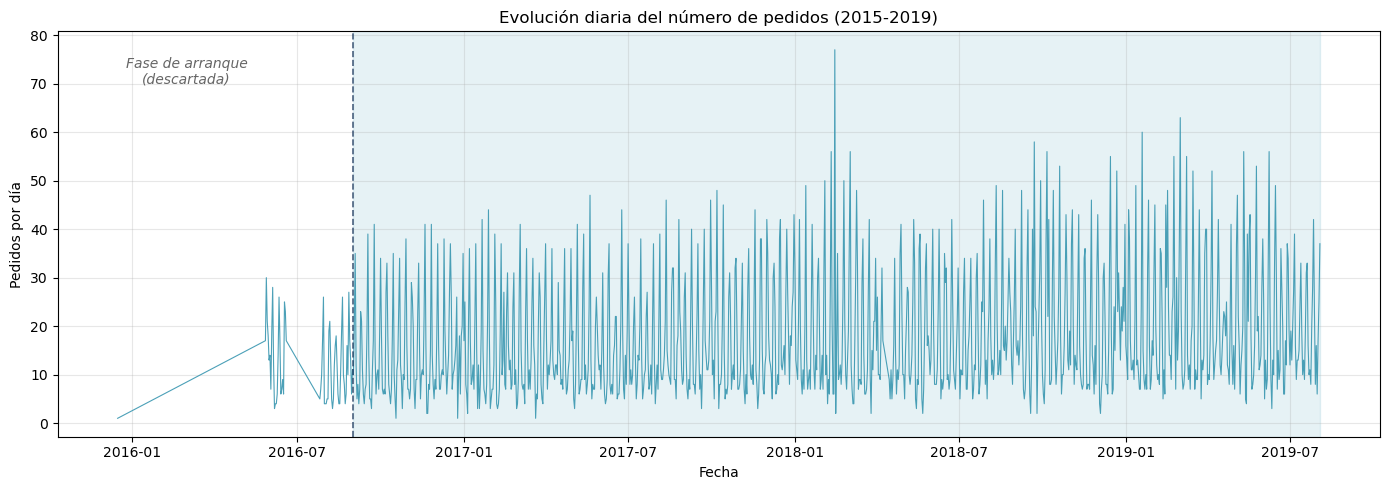

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Serie diaria de pedidos
fig, ax = plt.subplots(figsize=(14, 5))

# Línea principal de la serie
ax.plot(serie_diaria["fecha"], serie_diaria["n_pedidos"], 
        color="#3896b0", linewidth=0.8, alpha=0.9)

# Sombreado de la ventana de modelado
inicio_ventana = pd.Timestamp("2016-09-01")
fin_ventana = pd.Timestamp("2019-08-03")
ax.axvspan(inicio_ventana, fin_ventana, 
           alpha=0.12, color="#3896b0", 
           label="Ventana de modelado")

# Línea vertical de inicio de ventana
ax.axvline(x=inicio_ventana, color="#1f3a5f", linestyle="--", 
           linewidth=1.2, alpha=0.8)

# Anotación de la fase de arranque
ax.annotate("Fase de arranque\n(descartada)", 
            xy=(pd.Timestamp("2016-03-01"), 70),
            ha="center", fontsize=10, color="#666666", style="italic")

# Anotación de la ventana
ax.annotate("Ventana de modelado\n(1.067 días, 18.906 pedidos)\n8 días sin actividad (cierres puntuales)", 
            xy=(pd.Timestamp("2018-02-01"), 90),
            ha="center", fontsize=9, color="#1f3a5f", weight="bold")

ax.set_title("Evolución diaria del número de pedidos (2015-2019)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Identificar qué días dentro de la ventana NO tienen pedidos
inicio_ventana = pd.Timestamp("2016-09-01")
fin_ventana = pd.Timestamp("2019-08-03")

rango_completo = pd.date_range(start=inicio_ventana, end=fin_ventana, freq='D')
fechas_con_pedidos = set(serie_diaria[
    (serie_diaria["fecha"] >= inicio_ventana) & 
    (serie_diaria["fecha"] <= fin_ventana)
]["fecha"])

dias_sin_pedidos = sorted(set(rango_completo) - fechas_con_pedidos)
print(f"Días sin pedidos en la ventana: {len(dias_sin_pedidos)}")
for d in dias_sin_pedidos:
    print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

Días sin pedidos en la ventana: 8
  2017-12-25 (Monday)
  2018-04-09 (Monday)
  2018-04-10 (Tuesday)
  2018-04-11 (Wednesday)
  2018-04-12 (Thursday)
  2018-04-13 (Friday)
  2018-04-14 (Saturday)
  2018-12-25 (Tuesday)


In [31]:
serie_diaria[serie_diaria["fecha"] == pd.Timestamp("2016-12-25")]

,fecha,n_pedidos
176,2016-12-25,1


In [32]:
# Cobertura de días por año
serie_diaria['anio'] = pd.to_datetime(serie_diaria['fecha']).dt.year
dias_por_anio = {2015: 365, 2016: 366, 2017: 365, 2018: 365, 2019: 215}

cobertura = serie_diaria.groupby('anio').agg(
    dias_con_pedidos=('fecha', 'count'),
    pedidos_totales=('n_pedidos', 'sum'),
    media_pedidos_dia=('n_pedidos', 'mean')
).round(1)

cobertura['cobertura_pct'] = (
    cobertura['dias_con_pedidos'] / cobertura.index.map(dias_por_anio) * 100
).round(1)

print(cobertura)

      dias_con_pedidos  pedidos_totales  media_pedidos_dia  cobertura_pct
anio                                                                     
2015                 1                1                1.0            0.3
2016               182             2536               13.9           49.7
2017               364             5857               16.1           99.7
2018               358             6848               19.1           98.1
2019               215             4416               20.5          100.0


## 8. Selección de la ventana de modelado

El análisis visual y el resumen anual muestran una clara fase de arranque
del negocio entre diciembre de 2015 y el verano de 2016. Durante este
periodo la cobertura de datos es muy baja (0,3% en 2015 y 49,7% en 2016)
y el volumen medio de pedidos es reducido y muy volátil, lo que no
representa la operativa normal del restaurante.

A partir de 2017 la proporción de días con pedidos se estabiliza por encima
del 98% y el volumen medio de pedidos crece de forma sostenida 
(16,1 pedidos/día en 2017, 19,1 en 2018, 20,5 en 2019), lo que confirma
que el negocio ha alcanzado su funcionamiento habitual.

Se establece como fecha de inicio del periodo de modelado el 1 de
septiembre de 2016. Esta decisión descarta la fase de arranque y asegura
que el modelo trabaje sobre datos representativos del funcionamiento
habitual del restaurante. La ventana utilizada abarca 35 meses
(del 1 de septiembre de 2016 al 3 de agosto de 2019), suficiente para
capturar patrones estacionales anuales completos y realizar validación
cruzada en condiciones.

In [33]:
# Fecha de corte basada en el análisis exploratorio
FECHA_INICIO = pd.Timestamp("2016-09-01")
FECHA_FIN = pd.Timestamp("2019-08-03")

# Aplicamos el filtro temporal sobre la serie completa
serie_modelado = serie_diaria[
    (serie_diaria["fecha"] >= FECHA_INICIO) & 
    (serie_diaria["fecha"] <= FECHA_FIN)
].copy()

# Reindexamos con el rango completo para incluir los días sin pedidos
# (cierres puntuales del local). De esta forma, la serie cubre los 1.067
# días de la ventana sin huecos, requisito para Prophet y para el merge
# con el clima en el siguiente notebook.
rango_completo = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN, freq="D")
serie_modelado = (
    serie_modelado
    .set_index("fecha")
    .reindex(rango_completo)
    .rename_axis("fecha")
    .reset_index()
)

# Los días sin pedidos (cierres del local) se rellenan con 0
# Sabemos por el análisis previo que son 8 días: dos Navidades y una 
# semana de cierre por vacaciones del personal en abril de 2018
serie_modelado["n_pedidos"] = serie_modelado["n_pedidos"].fillna(0).astype(int)

# Verificamos la serie resultante
print(f"Ventana de modelado:      {serie_modelado['fecha'].min().date()} → {serie_modelado['fecha'].max().date()}")
print(f"Días totales:             {len(serie_modelado):,}")
print(f"Días sin pedidos:         {(serie_modelado['n_pedidos'] == 0).sum()}")
print(f"Pedidos totales:          {serie_modelado['n_pedidos'].sum():,}")
print(f"\nEstadísticas de pedidos por día:")
print(serie_modelado["n_pedidos"].describe().round(1))

Ventana de modelado:      2016-09-01 → 2019-08-03
Días totales:             1,067
Días sin pedidos:         8
Pedidos totales:          18,906

Estadísticas de pedidos por día:
count    1067.0
mean       17.7
std        12.4
min         0.0
25%         8.0
50%        13.0
75%        24.0
max        77.0
Name: n_pedidos, dtype: float64


## 9. Análisis de picos anómalos

Como cierre del notebook se realiza un análisis exploratorio adicional
para identificar días con un volumen de pedidos significativamente
superior al esperado para su día de la semana. El objetivo es detectar
fechas anómalas que puedan corresponderse con eventos puntuales no
capturados por el calendario oficial de festivos (festividades sociales
recurrentes como San Valentín, eventos masivos en el entorno del 
restaurante, etc.).

El criterio utilizado es el cálculo de la desviación de cada día
respecto a la mediana de su mismo día de la semana, expresada en
términos de desviaciones típicas (z-score). Se identifican los 15 días
con z-score más alto, candidatos a corresponderse con eventos
contextuales relevantes para la predicción.

Este análisis no modifica los datos del pipeline (los picos anómalos
se mantienen en la serie de modelado), pero proporciona evidencia
empírica que justifica la incorporación de un mecanismo de gestión
manual de eventos en el panel administrativo del sistema.

In [34]:
import pandas as pd

# Calculamos la mediana y desviación típica por día de la semana
serie_diaria['dia_semana'] = serie_diaria['fecha'].dt.day_name()
estadisticas_dow = serie_diaria.groupby('dia_semana')['n_pedidos'].agg(['median', 'std']).reset_index()

# Unimos las estadísticas con la serie original
serie_con_stats = serie_diaria.merge(estadisticas_dow, on='dia_semana')

# Calculamos el z-score: cuántas desviaciones típicas se aleja el pedido de la mediana de su día
serie_con_stats['desviacion'] = (serie_con_stats['n_pedidos'] - serie_con_stats['median']) / serie_con_stats['std']

# Top 15 días con desviación POSITIVA mayor (picos altos)
picos_altos = serie_con_stats.nlargest(15, 'desviacion')[['fecha', 'n_pedidos', 'dia_semana', 'median', 'desviacion']]
print("Top 15 picos altos:")
print(picos_altos.to_string(index=False))

print("\n\nTop 10 valles bajos (días con muchos menos pedidos):")
valles_bajos = serie_con_stats.nsmallest(10, 'desviacion')[['fecha', 'n_pedidos', 'dia_semana', 'median', 'desviacion']]
print(valles_bajos.to_string(index=False))

Top 15 picos altos:
     fecha  n_pedidos dia_semana  median  desviacion
2018-02-14         77  Wednesday     9.0    9.941904
2019-02-14         45   Thursday    11.0    5.966914
2018-10-08         42     Monday     8.0    5.409029
2018-12-31         41     Monday     8.0    5.249940
2018-09-20         40   Thursday    11.0    5.089427
2019-02-26         30    Tuesday     8.0    5.031161
2019-05-15         39  Wednesday     9.0    4.386134
2017-02-14         27    Tuesday     8.0    4.345093
2017-12-31         43     Sunday    18.0    4.010316
2018-01-01         32     Monday     8.0    3.818138
2018-12-24         31     Monday     8.0    3.659049
2019-03-31         40     Sunday    18.0    3.529078
2019-01-04         44     Friday    25.0    2.886269
2019-03-02         63   Saturday    38.0    2.874088
2018-04-02         26     Monday     8.0    2.863604


Top 10 valles bajos (días con muchos menos pedidos):
     fecha  n_pedidos dia_semana  median  desviacion
2016-12-25          1   

## 10. Persistencia del dataset procesado

Una vez construida la serie de trabajo, se guardan dos ficheros en
`data/processed/`:

- `serie_diaria_pedidos.csv`: la serie temporal agregada a nivel diario,
  que constituye la variable objetivo de los modelos predictivos.
- `pedidos_unicos.csv`: los pedidos individuales con su fecha y hora,
  que se utilizarán en los siguientes notebooks para análisis de
  granularidad fina (perfil horario, franjas de servicio).

Se utiliza el formato CSV por su simplicidad y compatibilidad.

In [35]:
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

ruta_salida = DATA_PROCESSED / "serie_diaria_pedidos.csv"
serie_modelado.to_csv(ruta_salida, index=False)

print(f"Serie guardada en: {ruta_salida}")
print(f"Tamaño: {ruta_salida.stat().st_size / 1024:.1f} KB")

# Guardamos también los pedidos únicos para análisis granulares posteriores
ruta_pedidos = DATA_PROCESSED / "pedidos_unicos.csv"
pedidos_unicos.to_csv(ruta_pedidos, index=False)
print(f"Pedidos únicos guardados en: {ruta_pedidos}")
print(f"Tamaño: {ruta_pedidos.stat().st_size / 1024:.1f} KB")

Serie guardada en: ..\data\processed\serie_diaria_pedidos.csv
Tamaño: 22.6 KB
Pedidos únicos guardados en: ..\data\processed\pedidos_unicos.csv
Tamaño: 808.5 KB


## 11. Resumen y próximos pasos

Al finalizar este notebook se ha obtenido una serie temporal diaria
del número de pedidos, limpia y lista para el entrenamiento de los
modelos predictivos. Las transformaciones aplicadas han sido:

- Carga y unificación de las columnas de pedidos de los dos restaurantes del dataset.
- Parseo explícito de las fechas en formato DD/MM/YYYY.
- Agregación de las líneas de producto a nivel de pedido único,
  confirmando los pedidos documentados en el análisis exploratorio.
- Descarte de la fase de arranque del negocio, estableciendo como
  ventana de entrenamiento el periodo del 1 de septiembre de 2016 al
  3 de agosto de 2019.

La serie se ha guardado en `data/processed/serie_diaria_pedidos.csv`.
El siguiente notebook (`02_enriquecimiento_datos.ipynb`) incorporará
las variables contextuales (meteorología mediante la API Open-Meteo y
festivos del Reino Unido mediante la librería `holidays`) que
constituyen la aportación diferencial del modelo principal frente al
modelo de referencia.